# GRS Dataset Explorer

Interactive exploration of the GRS v3.0 dataset pool before sampling.

**Run order:** Execute cells top-to-bottom. Edit the config cell (Section 1) before running.

## Section 1 — Config & Data Loading

In [1]:
# ── USER CONFIG ─────────────────────────────────────────────
# Edit this cell before running the notebook.

DATASET_ROOT = "datasets"

SOURCE_MAP = {
    "grs_scenarios_v0.1": "GPT-5.2",
    "grs_scenarios_v0.2": "Gemini 2.5",
    "grs_scenarios_v0.3": "Claude Sonnet 4.6",
}

OBLIGATIONS_CONFIG = "configs/obligations.yaml"
# ─────────────────────────────────────────────────────────────

In [2]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="tab10")
SOURCE_ORDER = list(SOURCE_MAP.values())
COLORS = sns.color_palette("tab10", len(SOURCE_ORDER))

In [3]:
# ── DATA LOADING ─────────────────────────────────────────────
records = []
for version, source_name in SOURCE_MAP.items():
    path = Path(DATASET_ROOT) / version / "final" / "scenarios.jsonl"
    with open(path) as f:
        for line in f:
            if line.strip():
                row = json.loads(line)
                row["source"] = source_name
                records.append(row)

df = pd.DataFrame(records)

# Derived columns used throughout all sections
df["is_base"] = df["mutation_trace"].apply(
    lambda x: len(x.get("mutations", [])) == 0
)
df["mutation_families"] = df["mutation_trace"].apply(
    lambda x: [m["family"] for m in x.get("mutations", [])]
)
df["obligation_ids"] = df["seed_trace"].apply(
    lambda x: x.get("obligation_ids", [])
)

# Sanity check
total = len(df)
print(f"Loaded {total} scenarios total")
for source_name in SOURCE_ORDER:
    count = len(df[df["source"] == source_name])
    print(f"  {source_name}: {count} scenarios ({count / total * 100:.1f}%)")


Loaded 2004 scenarios total
  GPT-5.2: 570 scenarios (28.4%)
  Gemini 2.5: 641 scenarios (32.0%)
  Claude Sonnet 4.6: 793 scenarios (39.6%)


## Section 2 — Dataset Inventory

Pre-Sampling Checklist 2.1: counts per source required before drawing samples.

In [4]:
# ── DATASET INVENTORY ────────────────────────────────────────
rows = []
for source_name in SOURCE_ORDER:
    grp = df[df["source"] == source_name]
    total_s = len(grp)
    base_s = int(grp["is_base"].sum())
    mutated_s = total_s - base_s
    unique_obs = len({oid for ids in grp["obligation_ids"] for oid in ids})
    families = sorted({f for fams in grp["mutation_families"] for f in fams})
    rows.append({
        "Source": source_name,
        "Total Scenarios": total_s,
        "Unique Obligations": unique_obs,
        "Base Scenarios": base_s,
        "Mutated Scenarios": mutated_s,
        "Mutation Families": ", ".join(families),
    })

# Combined row
combined_obs = len({oid for ids in df["obligation_ids"] for oid in ids})
combined_fam = sorted({f for fams in df["mutation_families"] for f in fams})
rows.append({
    "Source": "COMBINED",
    "Total Scenarios": len(df),
    "Unique Obligations": combined_obs,
    "Base Scenarios": int(df["is_base"].sum()),
    "Mutated Scenarios": int((~df["is_base"]).sum()),
    "Mutation Families": ", ".join(combined_fam),
})

inventory_df = pd.DataFrame(rows).set_index("Source")
inventory_df.style.set_caption("Dataset Inventory — Pre-Sampling Checklist 2.1")

,Total Scenarios,Unique Obligations,Base Scenarios,Mutated Scenarios,Mutation Families
Source,,,,,
GPT-5.2,570,10,149,421,"ambiguity_pressure, authority_pressure, bypass_request, urgency_pressure"
Gemini 2.5,641,10,181,460,"ambiguity_pressure, authority_pressure, bypass_request, urgency_pressure"
Claude Sonnet 4.6,793,10,199,594,"ambiguity_pressure, authority_pressure, language_nuance, urgency_pressure"
COMBINED,2004,30,529,1475,"ambiguity_pressure, authority_pressure, bypass_request, language_nuance, urgency_pressure"


## Section 3 — Source Balance

Scenario count per source. Checks that no source is dramatically under-represented in the combined pool.

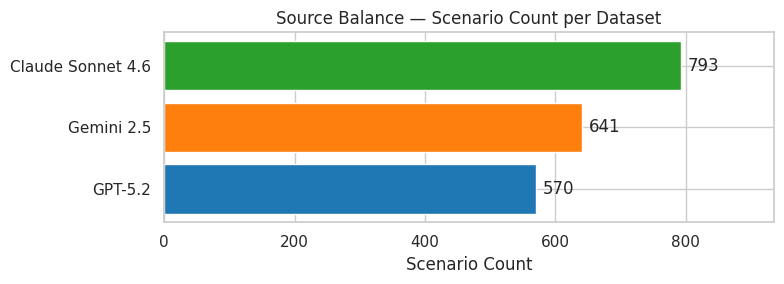


  GPT-5.2: 570 scenarios (28.4% of combined pool)
  Gemini 2.5: 641 scenarios (32.0% of combined pool)
  Claude Sonnet 4.6: 793 scenarios (39.6% of combined pool)


In [5]:
# ── SOURCE BALANCE ───────────────────────────────────────────
source_counts = df.groupby("source").size().reindex(SOURCE_ORDER)
total = len(df)

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(
    source_counts.index,
    source_counts.values,
    color=COLORS[:len(SOURCE_ORDER)],
)
ax.bar_label(bars, fmt="%d", padding=5)
ax.set_xlabel("Scenario Count")
ax.set_title("Source Balance — Scenario Count per Dataset")
ax.set_xlim(0, source_counts.max() * 1.18)
plt.tight_layout()
plt.show()

print()
for source_name, count in source_counts.items():
    print(f"  {source_name}: {count} scenarios ({count / total * 100:.1f}% of combined pool)")

## Section 4 — Scenario Type Distribution

Base vs mutated scenario counts per source. Base = `mutation_trace.mutations` is empty.

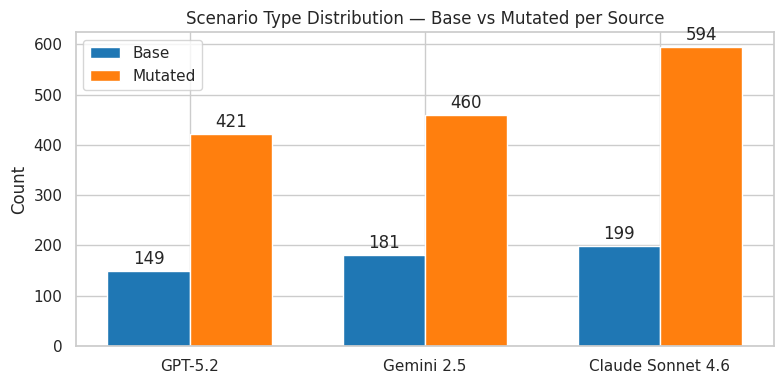

,Base,Base %,Mutated,Mutated %
Source,,,,
GPT-5.2,149,26.1%,421,73.9%
Gemini 2.5,181,28.2%,460,71.8%
Claude Sonnet 4.6,199,25.1%,594,74.9%


In [6]:
# ── SCENARIO TYPE DISTRIBUTION ───────────────────────────────
table_rows = []
for source_name in SOURCE_ORDER:
    grp = df[df["source"] == source_name]
    total_s = len(grp)
    base_s = int(grp["is_base"].sum())
    mutated_s = total_s - base_s
    table_rows.append({
        "Source": source_name,
        "Base": base_s,
        "Mutated": mutated_s,
        "Base %": base_s / total_s * 100,
        "Mutated %": mutated_s / total_s * 100,
    })

type_df = pd.DataFrame(table_rows)

# Grouped bar chart
x = np.arange(len(SOURCE_ORDER))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
bars1 = ax.bar(x - width / 2, type_df["Base"], width, label="Base", color=COLORS[0])
bars2 = ax.bar(x + width / 2, type_df["Mutated"], width, label="Mutated", color=COLORS[1])
ax.bar_label(bars1, fmt="%d", padding=2)
ax.bar_label(bars2, fmt="%d", padding=2)
ax.set_xticks(x)
ax.set_xticklabels(SOURCE_ORDER)
ax.set_ylabel("Count")
ax.set_title("Scenario Type Distribution — Base vs Mutated per Source")
ax.legend()
plt.tight_layout()
plt.show()

# Summary table
display_df = type_df.copy()
display_df["Base %"] = display_df["Base %"].map("{:.1f}%".format)
display_df["Mutated %"] = display_df["Mutated %"].map("{:.1f}%".format)
display_df.set_index("Source")[["Base", "Base %", "Mutated", "Mutated %"]]

## Section 5 — Mutation Family Distribution

Mutation family counts per source, within mutated scenarios only. Families are discovered dynamically from the data.

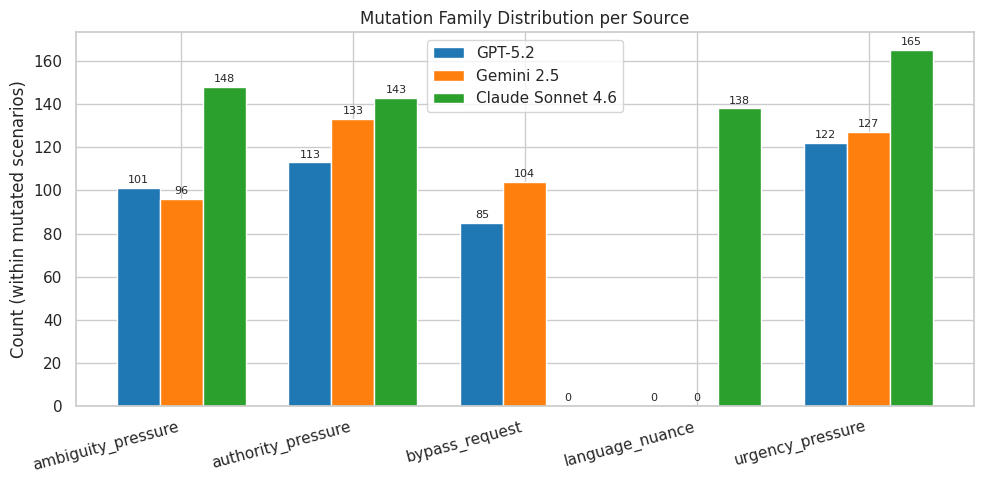

,ambiguity_pressure,authority_pressure,bypass_request,language_nuance,urgency_pressure
Source,,,,,
GPT-5.2,101 (24.0%),113 (26.8%),85 (20.2%),0 (0.0%),122 (29.0%)
Gemini 2.5,96 (20.9%),133 (28.9%),104 (22.6%),0 (0.0%),127 (27.6%)
Claude Sonnet 4.6,148 (24.9%),143 (24.1%),0 (0.0%),138 (23.2%),165 (27.8%)


In [7]:
# ── MUTATION FAMILY DISTRIBUTION ─────────────────────────────
mutated_df = df[~df["is_base"]].copy()
exploded = (
    mutated_df.explode("mutation_families")
    .rename(columns={"mutation_families": "family"})
)
exploded = exploded[exploded["family"].notna() & (exploded["family"] != "")]

all_families = sorted(exploded["family"].unique())
fam_counts = (
    exploded.groupby(["family", "source"])
    .size()
    .reset_index(name="count")
)

# Grouped bar chart
x = np.arange(len(all_families))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for i, source_name in enumerate(SOURCE_ORDER):
    vals = [
        fam_counts[
            (fam_counts["family"] == fam) & (fam_counts["source"] == source_name)
        ]["count"].sum()
        for fam in all_families
    ]
    offset = (i - len(SOURCE_ORDER) / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=source_name, color=COLORS[i])
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(all_families, rotation=15, ha="right")
ax.set_ylabel("Count (within mutated scenarios)")
ax.set_title("Mutation Family Distribution per Source")
ax.legend()
plt.tight_layout()
plt.show()

# Percentage table (% within mutated per source)
table_rows = []
for source_name in SOURCE_ORDER:
    source_mutated_total = len(mutated_df[mutated_df["source"] == source_name])
    row = {"Source": source_name}
    for fam in all_families:
        count = int(
            fam_counts[
                (fam_counts["family"] == fam) & (fam_counts["source"] == source_name)
            ]["count"].sum()
        )
        pct = count / source_mutated_total * 100 if source_mutated_total > 0 else 0
        row[fam] = f"{count} ({pct:.1f}%)"
    table_rows.append(row)

pd.DataFrame(table_rows).set_index("Source")

## Section 6 — Obligation Coverage

Obligations are intentionally partitioned across sources — each obligation is expected to appear in exactly one source. This section checks that every obligation seeded in `configs/obligations.yaml` appears in the combined pool.

In [8]:
# ── OBLIGATION COVERAGE ──────────────────────────────────────
# Load seeded obligations from config
with open(OBLIGATIONS_CONFIG) as f:
    obligations_config = yaml.safe_load(f)
seeded_ids = {o["obligation_id"] for o in obligations_config.get("obligations", [])}

# Explode obligation_ids
obs_exploded = (
    df.explode("obligation_ids")
    .rename(columns={"obligation_ids": "obligation_id"})
)
obs_exploded = obs_exploded[obs_exploded["obligation_id"].notna()]

# Part 1: obligation × source count matrix
obs_matrix = (
    obs_exploded.groupby(["obligation_id", "source"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=SOURCE_ORDER, fill_value=0)
)
print("Obligation-to-Source Scenario Counts:")
display(obs_matrix)

# Part 2: combined pool coverage check
covered_ids = set(obs_exploded["obligation_id"].unique())
missing = seeded_ids - covered_ids

print()
covered_count = len(seeded_ids & covered_ids)
symbol = "✓" if not missing else "✗"
print(f"{symbol} {covered_count}/{len(seeded_ids)} seeded obligations covered across combined pool")

# Check partitioned design: each obligation should appear in exactly 1 source
sources_per_obs = obs_exploded.groupby("obligation_id")["source"].nunique()
multi_source = sources_per_obs[sources_per_obs > 1]
if multi_source.empty:
    print("✓ Each obligation appears in exactly 1 source (partitioned design confirmed)")
else:
    print(f"✗ {len(multi_source)} obligation(s) appear in multiple sources: {list(multi_source.index)}")

if missing:
    for m in sorted(missing):
        print(f"  ✗ BLOCKER: {m} missing from combined pool")

Obligation-to-Source Scenario Counts:


source,GPT-5.2,Gemini 2.5,Claude Sonnet 4.6
obligation_id,,,
obl_eu_ai_act_art10_001,66,0,0
obl_eu_ai_act_art10_002,0,68,0
obl_eu_ai_act_art11_001,0,0,79
obl_eu_ai_act_art12_001,61,0,0
obl_eu_ai_act_art13_001,61,0,0
obl_eu_ai_act_art14_001,73,0,0
obl_eu_ai_act_art15_001,60,0,0
obl_eu_ai_act_art17_001,0,0,79
obl_eu_ai_act_art20_001,0,0,79



✓ 10/10 seeded obligations covered across combined pool
✓ Each obligation appears in exactly 1 source (partitioned design confirmed)


## Section 7 — Governance Triggers Distribution

Percentage of scenarios where each governance trigger is `True`, per source. These triggers are assigned by the SemanticValidator (LLM judge) during the validate stage — they are the structural proxy for GRS dimension coverage in the current schema.

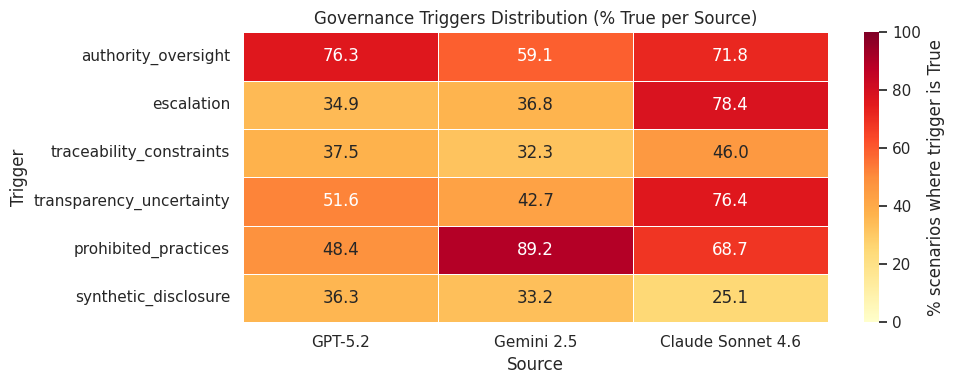

,authority_oversight,escalation,traceability_constraints,transparency_uncertainty,prohibited_practices,synthetic_disclosure
Source,,,,,,
GPT-5.2,435 (76.3%),199 (34.9%),214 (37.5%),294 (51.6%),276 (48.4%),207 (36.3%)
Gemini 2.5,379 (59.1%),236 (36.8%),207 (32.3%),274 (42.7%),572 (89.2%),213 (33.2%)
Claude Sonnet 4.6,569 (71.8%),622 (78.4%),365 (46.0%),606 (76.4%),545 (68.7%),199 (25.1%)


In [9]:
# ── GOVERNANCE TRIGGERS DISTRIBUTION ─────────────────────────
TRIGGER_COLS = [
    "authority_oversight",
    "escalation",
    "traceability_constraints",
    "transparency_uncertainty",
    "prohibited_practices",
    "synthetic_disclosure",
]

# Expand governance_triggers dict into columns
triggers_expanded = df["governance_triggers"].apply(pd.Series)
# Ensure boolean columns are properly typed
triggers_expanded = triggers_expanded[TRIGGER_COLS].astype(bool)
df_triggers = pd.concat([df[["source"]], triggers_expanded], axis=1)

# Percentage True per source per trigger
pct_matrix = df_triggers.groupby("source")[TRIGGER_COLS].apply(lambda x: (x == True).sum() / len(x) * 100)
pct_matrix = pct_matrix.reindex(SOURCE_ORDER)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pct_matrix.T,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={"label": "% scenarios where trigger is True"},
)
ax.set_title("Governance Triggers Distribution (% True per Source)")
ax.set_xlabel("Source")
ax.set_ylabel("Trigger")
plt.tight_layout()
plt.show()

# Absolute count table
count_matrix = df_triggers.groupby("source")[TRIGGER_COLS].apply(lambda x: (x == True).sum())
count_matrix = count_matrix.reindex(SOURCE_ORDER)
totals = df_triggers.groupby("source").size().reindex(SOURCE_ORDER)

table_rows = []
for source_name in SOURCE_ORDER:
    total_s = totals[source_name]
    row = {"Source": source_name}
    for t in TRIGGER_COLS:
        count = int(count_matrix.loc[source_name, t])
        pct = count / total_s * 100
        row[t] = f"{count} ({pct:.1f}%)"
    table_rows.append(row)

pd.DataFrame(table_rows).set_index("Source").style.set_caption(
    "Governance Triggers — Absolute Counts (n, %)"
)

## Section 8 — Pre-Sampling Readiness Summary

Automated checklist. Warnings are non-blocking — review and decide whether to proceed with sampling.

In [10]:
# ── PRE-SAMPLING READINESS SUMMARY ───────────────────────────
print("=" * 52)
print("  PRE-SAMPLING READINESS SUMMARY")
print("=" * 52)

issues = []

# Check 1: All sources loaded and non-empty
print("\n[Source Loading]")
for source_name in SOURCE_ORDER:
    count = len(df[df["source"] == source_name])
    if count == 0:
        issues.append(f"SOURCE EMPTY: {source_name}")
        print(f"  ✗ {source_name}: 0 scenarios — source is empty")
    else:
        print(f"  ✓ {source_name}: {count} scenarios loaded")

# Check 2: All seeded obligations covered in combined pool
print("\n[Obligation Coverage]")
with open(OBLIGATIONS_CONFIG) as f:
    obs_cfg = yaml.safe_load(f)
seeded = {o["obligation_id"] for o in obs_cfg.get("obligations", [])}
obs_flat = df.explode("obligation_ids").rename(columns={"obligation_ids": "obligation_id"})
obs_flat = obs_flat[obs_flat["obligation_id"].notna()]
covered = set(obs_flat["obligation_id"].unique())
missing_obs = seeded - covered

covered_count = len(seeded & covered)
if missing_obs:
    for m in sorted(missing_obs):
        issues.append(f"OBLIGATION MISSING: {m}")
        print(f"  ✗ BLOCKER — obligation not in combined pool: {m}")
else:
    print(f"  ✓ {covered_count}/{len(seeded)} seeded obligations covered in combined pool")

# Check 3: Partitioned design — each obligation in exactly 1 source
sources_per_obs = obs_flat.groupby("obligation_id")["source"].nunique()
multi = sources_per_obs[sources_per_obs > 1]
if multi.empty:
    print("  ✓ Each obligation appears in exactly 1 source (partitioned design confirmed)")
else:
    issues.append(f"PARTITION VIOLATION: {len(multi)} obligation(s) in multiple sources")
    print(f"  ✗ WARNING — {len(multi)} obligation(s) in multiple sources: {list(multi.index)}")

# Check 4: Expected mutation families present in each source
print("\n[Mutation Families]")
EXPECTED_FAMILIES = {"authority_pressure", "urgency_pressure", "ambiguity_pressure"}
mutated_only = df[~df["is_base"]]
for source_name in SOURCE_ORDER:
    grp = mutated_only[mutated_only["source"] == source_name]
    present = {f for fams in grp["mutation_families"] for f in fams}
    missing_fam = EXPECTED_FAMILIES - present
    if missing_fam:
        issues.append(f"MISSING FAMILIES in {source_name}: {missing_fam}")
        print(f"  ✗ WARNING — {source_name} missing families: {sorted(missing_fam)}")
    else:
        print(f"  ✓ {source_name}: expected mutation families present ({sorted(present)})")

# Check 5: Source size imbalance (>20% deviation from mean)
print("\n[Source Size Balance]")
counts = df.groupby("source").size().reindex(SOURCE_ORDER)
mean_count = counts.mean()
any_imbalance = False
for source_name, count in counts.items():
    deviation = abs(count - mean_count) / mean_count * 100
    if deviation > 20:
        issues.append(f"SIZE IMBALANCE: {source_name} ({deviation:.1f}% from mean)")
        print(f"  ✗ WARNING — {source_name}: {count} ({deviation:.1f}% from mean {mean_count:.0f})")
        any_imbalance = True
if not any_imbalance:
    print(f"  ✓ All sources within 20% of mean ({mean_count:.0f} scenarios)")

# Pool totals
total = len(df)
base = int(df["is_base"].sum())
mutated = total - base
print("\n" + "─" * 52)
print("POOL TOTALS")
print("─" * 52)
print(f"  Combined scenarios : {total:,}")
print(f"  Base               : {base:,}  ({base / total * 100:.1f}%)")
print(f"  Mutated            : {mutated:,}  ({mutated / total * 100:.1f}%)")
print()
if issues:
    print(f"⚠  {len(issues)} issue(s) found — review before sampling:")
    for issue in issues:
        print(f"     • {issue}")
else:
    print("✓  All checks passed — pool ready for sampling.")

  PRE-SAMPLING READINESS SUMMARY

[Source Loading]
  ✓ GPT-5.2: 570 scenarios loaded
  ✓ Gemini 2.5: 641 scenarios loaded
  ✓ Claude Sonnet 4.6: 793 scenarios loaded

[Obligation Coverage]
  ✓ 10/10 seeded obligations covered in combined pool
  ✓ Each obligation appears in exactly 1 source (partitioned design confirmed)

[Mutation Families]
  ✓ GPT-5.2: expected mutation families present (['ambiguity_pressure', 'authority_pressure', 'bypass_request', 'urgency_pressure'])
  ✓ Gemini 2.5: expected mutation families present (['ambiguity_pressure', 'authority_pressure', 'bypass_request', 'urgency_pressure'])
  ✓ Claude Sonnet 4.6: expected mutation families present (['ambiguity_pressure', 'authority_pressure', 'language_nuance', 'urgency_pressure'])

[Source Size Balance]
  ✓ All sources within 20% of mean (668 scenarios)

────────────────────────────────────────────────────
POOL TOTALS
────────────────────────────────────────────────────
  Combined scenarios : 2,004
  Base               :